# Part 02 — Structure-Aware GNN for Binding Affinity Prediction

This notebook focuses on learning from the protein-ligand graphs prepared in Part 1. The goal is to train a model that can estimate binding affinity from structural information and give us a practical scoring function for the later stages of the project.

Although the broader exercise is framed around EGFR kinase, obtaining a sufficiently large and consistent dataset of EGFR-specific protein-ligand complexes with both co-crystallized 3D structures and experimentally measured binding affinities is not straightforward. To keep the structure-based GNN task well supported by available data, I therefore use the PDBBind+ refined set, which provides curated 3D complexes paired with affinity labels in a format suitable for graph construction and supervised learning.


By the end of this notebook, we will have:
1. loaded the processed graph dataset,
2. defined and trained the GNN model,
3. checked how well it performs on validation and test data, and
4. saved the trained model for use in the next stage.

## 1. Imports and Configuration

In [1]:
import sys, os, warnings, json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# MPS lacks scatter_reduce support needed by HGTConv — force CPU
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import HGTConv, Linear, global_mean_pool, global_add_pool
from torch_geometric.nn.aggr import AttentionalAggregation

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import MLFlowLogger

warnings.filterwarnings("ignore")
torch.manual_seed(42)

# ── Paths ────────────────────────────────────────────────────────────────
ROOT         = Path("..").resolve()
DATA_DIR     = ROOT / "data"
PROCESSED    = DATA_DIR / "processed"
CKPT_DIR     = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

# ── Dims (must match Phase 1 featurization) ──────────────────────────────
LIGAND_NODE_DIM  = 28
PROTEIN_NODE_DIM = 26

# ── Hyperparameters ──────────────────────────────────────────────────────
HID_DIM    = 128    # hidden channels in GNN
N_LAYERS   = 4      # HGTConv message-passing layers
N_HEADS    = 4      # attention heads per HGTConv layer
DROPOUT    = 0.1
LR         = 3e-4
BATCH_SIZE = 8
MAX_EPOCHS = 30     # capped for dry-run; increase to 100 for full training
PATIENCE   = 10

# MTL loss weights  (affinity · pose · selectivity)
LOSS_WEIGHTS = {"affinity": 1.0, "pose": 0.3, "selectivity": 0.3}

print(f"Torch: {torch.__version__}")
# HGTConv scatter_reduce not supported on MPS — use CPU
DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

Torch: 2.3.1
Device: cpu


## 2. Load the Dataset from 01 notebook

The graphs prepared in the first notebook are loaded here and wrapped for training.

In [2]:
cache_path = PROCESSED / "dataset.pt"
assert cache_path.exists(), (
    f"dataset.pt not found at {cache_path}\n"
    "Run phase1_data_graph_pipeline.ipynb first to build and cache graphs."
)

all_graphs = torch.load(cache_path, weights_only=False)
print(f"Loaded {len(all_graphs)} graphs from cache")

# ── Splits: 80 / 10 / 10 ────────────────────────────────────────────────
idx = list(range(len(all_graphs)))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_data = [all_graphs[i] for i in train_idx]
val_data   = [all_graphs[i] for i in val_idx]
test_data  = [all_graphs[i] for i in test_idx]

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_loader = PyGLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = PyGLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = PyGLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Quick sanity check
b = next(iter(train_loader))
print(f"\nBatch ligand  x : {b['ligand'].x.shape}")
print(f"Batch residue x : {b['residue'].x.shape}")
print(f"y_affinity      : {b.y_affinity.squeeze()}")
print(f"y_pose          : {b.y_pose.squeeze()}")

Loaded 150 graphs from cache
Train: 120 | Val: 15 | Test: 15

Batch ligand  x : torch.Size([239, 28])
Batch residue x : torch.Size([228, 26])
y_affinity      : tensor([6.5600, 6.5000, 4.7000, 7.0700, 7.1000, 6.8700, 6.7800, 6.4000])
y_pose          : tensor([1., 1., 0., 1., 1., 1., 1., 0.])


## 3. `HeteroGNN` Architecture

The main objective is binding affinity prediction, while pose and selectivity are included as auxiliary tasks to regularize the shared encoder. Here, `y_pose` is a binary proxy derived from whether pKd is above the dataset median, and `y_select` is a placeholder label fixed at zero for all samples. This makes the model better described as an affinity predictor with multi-task regularization.



![Model architecture](../Figs/GNN-model-arch.png)

In [3]:
class HeteroGNN(nn.Module):
    """
    4-layer Heterogeneous Graph Transformer for protein-ligand binding affinity.
    Handles 2 node types (ligand, residue) and 4 edge types.
    """

    NODE_TYPES = ["ligand", "residue"]
    EDGE_TYPES = [
        ("ligand",  "bond",       "ligand"),
        ("residue", "contact",    "residue"),
        ("residue", "interacts",  "ligand"),
        ("ligand",  "interacts",  "residue"),
    ]
    META = (NODE_TYPES, EDGE_TYPES)

    def __init__(
        self,
        lig_in:   int = LIGAND_NODE_DIM,
        prot_in:  int = PROTEIN_NODE_DIM,
        hidden:   int = HID_DIM,
        n_layers: int = N_LAYERS,
        n_heads:  int = N_HEADS,
        dropout:  float = DROPOUT,
        multitask: bool = True,
    ):
        super().__init__()
        self.multitask = multitask
        self.n_layers  = n_layers

        # ── Input projections ──────────────────────────────────────────
        self.lig_proj  = nn.Sequential(
            nn.Linear(lig_in,  hidden), nn.LayerNorm(hidden), nn.ReLU()
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(prot_in, hidden), nn.LayerNorm(hidden), nn.ReLU()
        )

        # ── HGTConv layers + layer norms + residual ────────────────────
        self.convs = nn.ModuleList([
            HGTConv(
                in_channels  = {nt: hidden for nt in self.NODE_TYPES},
                out_channels = hidden,
                metadata     = self.META,
                heads        = n_heads,
            )
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([
            nn.ModuleDict({
                nt: nn.LayerNorm(hidden) for nt in self.NODE_TYPES
            })
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        # ── Attention pooling readout (separate gate per node type) ────
        self.lig_pool  = AttentionalAggregation(gate_nn=nn.Linear(hidden, 1))
        self.prot_pool = AttentionalAggregation(gate_nn=nn.Linear(hidden, 1))

        # ── Shared MLP trunk ───────────────────────────────────────────
        self.trunk = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
        )

        # ── Output heads ───────────────────────────────────────────────
        head_in = hidden // 2
        self.affinity_head    = nn.Linear(head_in, 1)
        self.pose_head        = nn.Linear(head_in, 1)      # active only if multitask
        self.selectivity_head = nn.Linear(head_in, 1)      # active only if multitask

    def forward(self, batch: HeteroData) -> Dict[str, torch.Tensor]:
        # ── Project inputs to hidden dim ──────────────────────────────
        x_dict = {
            "ligand":  self.lig_proj(batch["ligand"].x),
            "residue": self.prot_proj(batch["residue"].x),
        }

        # Build edge_index_dict — skip missing edge types gracefully
        edge_index_dict = {}
        for et in self.EDGE_TYPES:
            try:
                edge_index_dict[et] = batch[et].edge_index
            except (AttributeError, KeyError):
                pass  # HGTConv tolerates missing edge types

        # ── 4 message-passing layers with residual + LayerNorm ────────
        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, edge_index_dict)
            for nt in self.NODE_TYPES:
                if nt in x_new and x_new[nt] is not None:
                    x_dict[nt] = norm_dict[nt](
                        self.dropout(x_new[nt]) + x_dict[nt]   # residual
                    )

        # ── Attention pooling → graph-level embeddings ────────────────
        lig_emb  = self.lig_pool(x_dict["ligand"],
                                  batch["ligand"].batch)
        prot_emb = self.prot_pool(x_dict["residue"],
                                   batch["residue"].batch)

        # ── Shared trunk ──────────────────────────────────────────────
        graph_emb = self.trunk(torch.cat([lig_emb, prot_emb], dim=-1))

        # ── Heads ─────────────────────────────────────────────────────
        out = {"affinity": self.affinity_head(graph_emb).squeeze(-1)}
        if self.multitask:
            out["pose"]        = self.pose_head(graph_emb).squeeze(-1)
            out["selectivity"] = self.selectivity_head(graph_emb).squeeze(-1)
        return out


# ── Quick shape check ─────────────────────────────────────────────────────
model_test = HeteroGNN().to(DEVICE)

sample_batch = None
if "train_loader" in globals():
    sample_batch = next(iter(train_loader))
elif "train_data" in globals() and len(train_data) > 0:
    sample_batch = next(iter(PyGLoader(train_data[: min(BATCH_SIZE, len(train_data))], batch_size=min(BATCH_SIZE, len(train_data)), shuffle=False, num_workers=0)))
elif "all_graphs" in globals() and len(all_graphs) > 0:
    sample_batch = next(iter(PyGLoader(all_graphs[: min(BATCH_SIZE, len(all_graphs))], batch_size=min(BATCH_SIZE, len(all_graphs)), shuffle=False, num_workers=0)))

if sample_batch is None:
    print("Run the dataset-loading cell first to create a sample batch for the shape check.")
else:
    b_test = sample_batch.to(DEVICE)
    with torch.no_grad():
        out_test = model_test(b_test)

    print("Forward pass OK")
    for k, v in out_test.items():
        print(f"  {k}: {v.shape}  sample={v[:3].cpu().numpy().round(3)}")

    total_params = sum(p.numel() for p in model_test.parameters())
    print(f"\nTotal parameters: {total_params:,}")


Forward pass OK
  affinity: torch.Size([8])  sample=[0.224 0.121 0.174]
  pose: torch.Size([8])  sample=[0.278 0.173 0.219]
  selectivity: torch.Size([8])  sample=[-0.057  0.041  0.074]

Total parameters: 711,117


## 4. Multi-Task Loss

This cell defines the training loss for the model. It combines the prediction errors from the affinity, pose, and selectivity outputs into a single objective, with the contribution of each task balanced automatically through learned uncertainty weights.

`MTLLoss` combines the losses from the affinity, pose, and selectivity heads into a single training objective. Affinity is treated as a regression task using MSE loss, while pose and selectivity are treated as binary classification tasks using BCE loss. Instead of assigning fixed manual weights, the model learns an uncertainty term for each task, which lets it automatically balance their relative contribution during training.

In [4]:
class MTLLoss(nn.Module):
    """
    Multi-task loss with learned uncertainty weighting (Kendall et al. 2018).
    
    Instead of fixed weights, learn log(sigma^2) per task.
    Loss_i = (1/2σ_i²) * task_loss_i + log(σ_i)
    
    This auto-balances tasks during training without manual tuning.
    Falls back to fixed weights when multitask=False.
    """

    def __init__(self, multitask: bool = True,
                 weights: Dict[str, float] = LOSS_WEIGHTS):
        super().__init__()
        self.multitask = multitask
        self.weights   = weights

        if multitask:
            # Learnable log variances — one per task
            self.log_var_aff  = nn.Parameter(torch.zeros(1))
            self.log_var_pose = nn.Parameter(torch.zeros(1))
            self.log_var_sel  = nn.Parameter(torch.zeros(1))

    def forward(self, preds: Dict[str, torch.Tensor],
                batch: HeteroData) -> Tuple[torch.Tensor, Dict[str, float]]:

        y_aff  = batch.y_affinity.squeeze().to(preds["affinity"].device)
        loss_aff = F.mse_loss(preds["affinity"], y_aff)

        components = {"loss_affinity": loss_aff.item()}

        if not self.multitask:
            return loss_aff, components

        # Pose quality head
        y_pose = batch.y_pose.squeeze().to(preds["pose"].device)
        loss_pose = F.binary_cross_entropy_with_logits(preds["pose"], y_pose)
        components["loss_pose"] = loss_pose.item()

        # Selectivity head
        y_sel = batch.y_select.squeeze().to(preds["selectivity"].device)
        loss_sel = F.binary_cross_entropy_with_logits(preds["selectivity"], y_sel)
        components["loss_selectivity"] = loss_sel.item()

        # Uncertainty-weighted combination
        loss = (
            torch.exp(-self.log_var_aff)  * loss_aff  + 0.5 * self.log_var_aff
          + torch.exp(-self.log_var_pose) * loss_pose + 0.5 * self.log_var_pose
          + torch.exp(-self.log_var_sel)  * loss_sel  + 0.5 * self.log_var_sel
        )
        components["loss_total"] = loss.item()
        components["sigma_aff"]  = float(torch.exp(0.5 * self.log_var_aff).item())
        components["sigma_pose"] = float(torch.exp(0.5 * self.log_var_pose).item())
        components["sigma_sel"]  = float(torch.exp(0.5 * self.log_var_sel).item())
        return loss, components


# Sanity check
if "out_test" not in globals() or "b_test" not in globals():
    print("Run the HeteroGNN shape-check cell after loading data to test the loss.")
else:
    criterion_test = MTLLoss(multitask=True)
    loss_val, comps = criterion_test(out_test, b_test.cpu())
    print(f"MTL loss: {loss_val.item():.4f}")
    for k, v in comps.items():
        print(f"  {k}: {v:.4f}")


MTL loss: 54.4672
  loss_affinity: 53.1350
  loss_pose: 0.6386
  loss_selectivity: 0.6936
  loss_total: 54.4672
  sigma_aff: 1.0000
  sigma_pose: 1.0000
  sigma_sel: 1.0000


## 5. PyTorch Lightning Module

This section wraps the model, loss computation, metrics, and optimizer setup in a Lightning module. That keeps the training loop readable and makes checkpointing and logging much less error-prone.

In [5]:
class GNNBindModule(pl.LightningModule):
    """
    PyTorch Lightning wrapper for HeteroGNN.
    Tracks: train/val RMSE, Pearson R, pose AUC, selectivity AUC.
    """

    def __init__(self, multitask: bool = True, lr: float = LR):
        super().__init__()
        self.save_hyperparameters()
        self.model     = HeteroGNN(multitask=multitask)
        self.criterion = MTLLoss(multitask=multitask)
        self.multitask = multitask
        self.lr        = lr

        self._val_preds       = []
        self._val_labels      = []
        self._val_pose_logits = []
        self._val_pose_labels = []

    def training_step(self, batch, batch_idx):
        preds = self.model(batch)
        loss, comps = self.criterion(preds, batch)
        self.log("train/loss", loss, prog_bar=True, batch_size=BATCH_SIZE)
        for k, v in comps.items():
            self.log(f"train/{k}", v, batch_size=BATCH_SIZE)
        return loss

    def validation_step(self, batch, batch_idx):
        preds = self.model(batch)
        loss, _ = self.criterion(preds, batch)
        self.log("val/loss", loss, prog_bar=True, batch_size=BATCH_SIZE)
        self._val_preds.append(preds["affinity"].detach().cpu())
        self._val_labels.append(batch.y_affinity.squeeze().cpu())
        if self.multitask:
            self._val_pose_logits.append(preds["pose"].detach().cpu())
            self._val_pose_labels.append(batch.y_pose.squeeze().cpu())

    def on_validation_epoch_end(self):
        if not self._val_preds:
            return
        preds  = torch.cat(self._val_preds).numpy()
        labels = torch.cat(self._val_labels).numpy()
        rmse = float(np.sqrt(np.mean((preds - labels) ** 2)))
        r, _ = pearsonr(preds, labels) if len(preds) > 2 else (0.0, 1.0)
        # log both namespaced (for display) and flat (for checkpoint filename)
        self.log("val/rmse",    rmse, prog_bar=True)
        self.log("val/pearson", r,    prog_bar=True)
        self.log("val_rmse",    rmse)   # flat name — used in ModelCheckpoint filename

        if self.multitask and self._val_pose_logits:
            pose_logits = torch.cat(self._val_pose_logits).sigmoid().numpy()
            pose_labels = torch.cat(self._val_pose_labels).numpy()
            if len(np.unique(pose_labels)) > 1:
                self.log("val/pose_auc", roc_auc_score(pose_labels, pose_logits))

        self._val_preds.clear(); self._val_labels.clear()
        self._val_pose_logits.clear(); self._val_pose_labels.clear()

    def configure_optimizers(self):
        opt = Adam(self.parameters(), lr=self.lr, weight_decay=1e-5)
        sched = ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5, min_lr=1e-6)
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "monitor": "val/loss", "interval": "epoch"},
        }


print("GNNBindModule defined.")

GNNBindModule defined.


## 6. Train the Multi-Task Model (MTL)

In [6]:
callbacks_mtl = [
    EarlyStopping(monitor="val/loss", patience=PATIENCE, mode="min", verbose=False),
    ModelCheckpoint(
        dirpath=str(CKPT_DIR),
        filename="gnn_mtl-{epoch:02d}-{val_rmse:.3f}",
        monitor="val/rmse",
        mode="min",
        save_top_k=1,
        verbose=True,
    ),
]

module_mtl = GNNBindModule(multitask=True, lr=LR)

trainer_mtl = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=callbacks_mtl,
    enable_progress_bar=False,
    enable_model_summary=True,
    log_every_n_steps=1,
    accelerator="cpu",
)

print("Training MTL model …")
trainer_mtl.fit(module_mtl, train_loader, val_loader)
print(f"Best MTL checkpoint: {callbacks_mtl[1].best_model_path}")
print(f"Best val RMSE      : {callbacks_mtl[1].best_model_score:.4f}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training MTL model …


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ HeteroGNN │  711 K │ train │     0 │
│ 1 │ criterion │ MTLLoss   │      3 │ train │     0 │
└───┴───────────┴───────────┴────────┴───────┴───────┘

Trainable params: 711 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 711 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 95                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 0, global step 15: 'val/rmse' reached 5.31185 (best 5.31185), saving model to '/Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=00-val_rmse=5.312.ckpt' as top 1
Epoch 1, global step 30: 'val/rmse' reached 4.51618 (best 4.51618), saving model to '/Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=01-val_rmse=4.516.ckpt' as top 1
Epoch 2, global step 45: 'val/rmse' reached 3.58148 (best 3.58148), saving model to '/Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=02-val_rmse=3.581.ckpt' as top 1
Epoch 3, global step 60: 'val/rmse' reached 2.80109 (best 2.80109), saving model to '/Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=03-val_rmse=2.801.ckpt' as top 1
Epoch 4, global step 75: 'val/rmse' reached 2.29779 (best 2.29779), saving model to '/Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=04-val_rmse=2.298.ckpt' as top 1
Epoch 5, global step 90: 'val/rmse'

Best MTL checkpoint: /Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=19-val_rmse=1.924-v6.ckpt
Best val RMSE      : 1.9244


## 7. Ablation: Single-Task Model (STL)

To tell a credible story, the multi-task model needs a fair comparison point. This section trains a binding-affinity-only baseline model so we can test whether the auxiliary tasks are genuinely helping or just adding complexity.

In [7]:
callbacks_stl = [
    EarlyStopping(monitor="val/loss", patience=PATIENCE, mode="min", verbose=False),
    ModelCheckpoint(
        dirpath=str(CKPT_DIR),
        filename="gnn_stl-{epoch:02d}-{val_rmse:.3f}",
        monitor="val/rmse",
        mode="min",
        save_top_k=1,
        verbose=False,
    ),
]

module_stl = GNNBindModule(multitask=False, lr=LR)

trainer_stl = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=callbacks_stl,
    enable_progress_bar=False,
    enable_model_summary=False,
    log_every_n_steps=1,
    accelerator="cpu",
)

print("Training STL (single-task, affinity-only) model …")
trainer_stl.fit(module_stl, train_loader, val_loader)
print(f"Best STL checkpoint: {callbacks_stl[1].best_model_path}")
print(f"Best val RMSE      : {callbacks_stl[1].best_model_score:.4f}")

# ── Ablation summary ──────────────────────────────────────────────────────
mtl_rmse = float(callbacks_mtl[1].best_model_score)
stl_rmse = float(callbacks_stl[1].best_model_score)
delta    = stl_rmse - mtl_rmse
print(f"\n{'='*45}")
print(f"  MTL (pose + selectivity aux tasks) : {mtl_rmse:.4f}")
print(f"  STL (affinity only)                : {stl_rmse:.4f}")
print(f"  Δ RMSE (positive = MTL wins)       : {delta:+.4f}")
print(f"{'='*45}")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training STL (single-task, affinity-only) model …
Best STL checkpoint: /Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_stl-epoch=09-val_rmse=2.034-v6.ckpt
Best val RMSE      : 2.0337

  MTL (pose + selectivity aux tasks) : 1.9244
  STL (affinity only)                : 2.0337
  Δ RMSE (positive = MTL wins)       : +0.1093


## 8. Test Set Evaluation

Once training is complete, I evaluate the final models on the held-out test set. This is where the comparison between the single-task and multi-task setups becomes meaningful.

In [8]:
def evaluate_on_test(module: GNNBindModule, loader, device=DEVICE):
    """Run test set inference; return dict of metrics + raw arrays."""
    module.eval().to(device)
    all_preds, all_labels = [], []
    all_pose_logits, all_pose_labels = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            preds = module.model(batch)
            all_preds.append(preds["affinity"].cpu())
            all_labels.append(batch.y_affinity.squeeze().cpu())
            if module.multitask:
                all_pose_logits.append(preds["pose"].cpu())
                all_pose_labels.append(batch.y_pose.squeeze().cpu())

    p = torch.cat(all_preds).numpy()
    y = torch.cat(all_labels).numpy()
    rmse = float(np.sqrt(np.mean((p - y) ** 2)))
    mae  = float(np.mean(np.abs(p - y)))
    r, _ = pearsonr(p, y)

    metrics = {"rmse": rmse, "mae": mae, "pearson_r": r}

    if module.multitask and all_pose_logits:
        pl_logits = torch.cat(all_pose_logits).sigmoid().numpy()
        pl_labels = torch.cat(all_pose_labels).numpy()
        if len(np.unique(pl_labels)) > 1:
            metrics["pose_auc"] = roc_auc_score(pl_labels, pl_logits)

    return metrics, p, y


def resolve_best_checkpoint(preferred_path: str, pattern: str) -> Path:
    preferred = Path(preferred_path) if preferred_path else None
    if preferred and preferred.exists():
        return preferred
    matches = sorted(CKPT_DIR.glob(pattern))
    if matches:
        return matches[-1]
    raise FileNotFoundError(f"No checkpoint found for pattern: {pattern}")


best_mtl_path = resolve_best_checkpoint(
    getattr(callbacks_mtl[1], "best_model_path", ""),
    "gnn_mtl-*.ckpt",
)
best_stl_path = resolve_best_checkpoint(
    getattr(callbacks_stl[1], "best_model_path", ""),
    "gnn_stl-*.ckpt",
)

module_best     = GNNBindModule.load_from_checkpoint(best_mtl_path)
module_stl_best = GNNBindModule.load_from_checkpoint(best_stl_path)

test_metrics_mtl, test_preds_mtl, test_labels = evaluate_on_test(module_best, test_loader)
test_metrics_stl, test_preds_stl, test_labels_stl = evaluate_on_test(module_stl_best, test_loader)

if not np.allclose(test_labels, test_labels_stl):
    print("Warning: test label order differs between MTL and STL evaluation.")

print("── Test Set Results (MTL model) ──────────────────")
for k, v in test_metrics_mtl.items():
    print(f"  {k:15s}: {v:.4f}")
print("──────────────────────────────────────────────────")

print("── Test Set Results (STL model) ──────────────────")
for k, v in test_metrics_stl.items():
    print(f"  {k:15s}: {v:.4f}")
print("──────────────────────────────────────────────────")


── Test Set Results (MTL model) ──────────────────
  rmse           : 1.7022
  mae            : 1.4918
  pearson_r      : 0.5786
  pose_auc       : 0.7963
──────────────────────────────────────────────────
── Test Set Results (STL model) ──────────────────
  rmse           : 1.6830
  mae            : 1.2809
  pearson_r      : 0.6032
──────────────────────────────────────────────────


## 9. Visualizations

The figure below compares held-out test-set predictions from the two trained models in a simple 1×2 layout. Panel `a)` shows the **multi-task model (MTL)** and panel `b)` shows the **single-task baseline (STL)**, so the difference in fit can be inspected directly rather than through a derived summary plot.


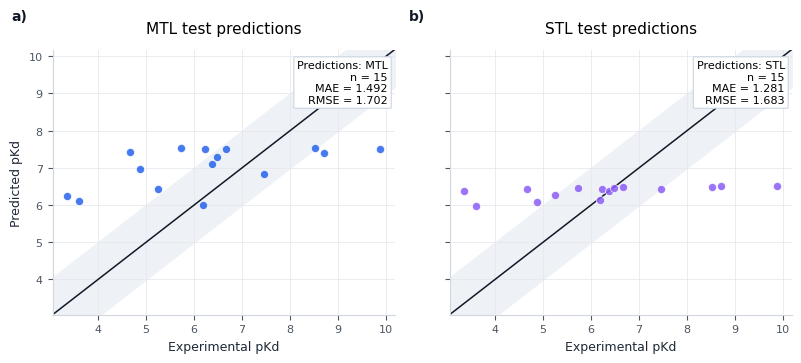

Figure saved → checkpoints/phase2_results.png


In [9]:
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#D0D7DE",
    "axes.labelcolor": "#1F2937",
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.9), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

lo = min(test_labels.min(), test_preds_mtl.min(), test_preds_stl.min()) - 0.3
hi = max(test_labels.max(), test_preds_mtl.max(), test_preds_stl.max()) + 0.3
band = 1.0

panels = [
    (axes[0], test_preds_mtl, test_metrics_mtl, "MTL test predictions", "#2563EB", "a)", "Predictions: MTL"),
    (axes[1], test_preds_stl, test_metrics_stl, "STL test predictions", "#8B5CF6", "b)", "Predictions: STL"),
]

for ax, preds, metrics, title, color, panel_label, box_label in panels:
    ax.fill_between(
        [lo, hi],
        [lo - band, hi - band],
        [lo + band, hi + band],
        color="#EEF2F7",
        alpha=1.0,
        zorder=0,
    )
    ax.scatter(
        test_labels,
        preds,
        alpha=0.85,
        s=34,
        color=color,
        edgecolors="white",
        linewidths=0.55,
        zorder=3,
    )
    ax.plot([lo, hi], [lo, hi], linestyle="-", color="#111827", lw=1.1, zorder=2)
    ax.set_title(title, pad=12)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(axis="both", color="#E5E7EB", linewidth=0.7, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    stats_text = (
        f"{box_label}\n"
        f"n = {len(test_labels)}\n"
        f"MAE = {metrics['mae']:.3f}\n"
        f"RMSE = {metrics['rmse']:.3f}"
    )
    ax.text(
        0.98,
        0.96,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.30,rounding_size=0.12",
            facecolor="white",
            edgecolor="#CBD5E1",
            linewidth=0.8,
        ),
    )
    ax.text(
        -0.12,
        1.10,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#111827",
    )

axes[0].set_xlabel("Experimental pKd")
axes[1].set_xlabel("Experimental pKd")
axes[0].set_ylabel("Predicted pKd")

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.18, top=0.86, wspace=0.16)
plt.savefig(str(ROOT / "checkpoints" / "phase2_results.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved → checkpoints/phase2_results.png")


## 10. Export the Model for Part 3

The trained checkpoint is saved here so it can be reused as a frozen scoring oracle in the reinforcement learning notebook. 

In [10]:
import shutil

SRC_MODELS = ROOT / "src" / "models"
SRC_MODELS.mkdir(parents=True, exist_ok=True)

# Copy best checkpoint to src/models/ so Phase 3 can import it
dst = SRC_MODELS / "gnn_best.ckpt"
shutil.copy2(best_mtl_path, dst)
print(f"Checkpoint copied → {dst}")

# Also save a lightweight state dict for inference
state = {
    "model_state_dict": module_best.model.state_dict(),
    "hparams": {
        "multitask":  True,
        "lig_in":     LIGAND_NODE_DIM,
        "prot_in":    PROTEIN_NODE_DIM,
        "hidden":     HID_DIM,
        "n_layers":   N_LAYERS,
        "n_heads":    N_HEADS,
        "dropout":    DROPOUT,
    },
    "test_metrics": test_metrics_mtl,
}
torch.save(state, SRC_MODELS / "gnn_state.pt")
print(f"State dict  saved → {SRC_MODELS / 'gnn_state.pt'}")

print("\n── Phase 2 complete ──────────────────────────────")
print(f"  Best checkpoint : {best_mtl_path}")
print(f"  Test RMSE       : {test_metrics_mtl['rmse']:.4f}")
print(f"  Test Pearson r  : {test_metrics_mtl['pearson_r']:.4f}")
if "pose_auc" in test_metrics_mtl:
    print(f"  Pose AUC        : {test_metrics_mtl['pose_auc']:.4f}")
print("  → Ready for Part 3: RL molecular generator")


Checkpoint copied → /Users/sourav/personal-github/gnn-bind-optimizer/src/models/gnn_best.ckpt
State dict  saved → /Users/sourav/personal-github/gnn-bind-optimizer/src/models/gnn_state.pt

── Phase 2 complete ──────────────────────────────
  Best checkpoint : /Users/sourav/personal-github/gnn-bind-optimizer/checkpoints/gnn_mtl-epoch=19-val_rmse=1.924-v6.ckpt
  Test RMSE       : 1.7022
  Test Pearson r  : 0.5786
  Pose AUC        : 0.7963
  → Ready for Part 3: RL molecular generator
